# Credit Card Fraud Detection - EDA

Exploratory Data Analysis on the Kaggle Credit Card Fraud dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 6)

# Absolute path for notebook execution
DATA_PATH = '/Users/maitranhuy/fraud-detection/data/raw/creditcard.csv'
DOCS_PATH = '/Users/maitranhuy/fraud-detection/docs'
os.makedirs(DOCS_PATH, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 1. Basic Info

In [2]:
print('=== Dataset Info ===')
print(df.info())
print(f'\n=== Missing Values: {df.isnull().sum().sum()} ===')
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  fl

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.759061e-12,-8.251130e-13,-9.654937e-13,8.321385e-13,1.649999e-13,4.248366e-13,-3.054600e-13,8.777971e-14,-1.179749e-12,...,-3.405756e-13,-5.723197e-13,-9.725856e-13,1.464150e-12,-6.987102e-13,-5.617874e-13,3.332082e-12,-3.518874e-12,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## 2. Class Imbalance

Legitimate (0): 284315 (99.83%)
Fraud (1):     492 (0.1727%)


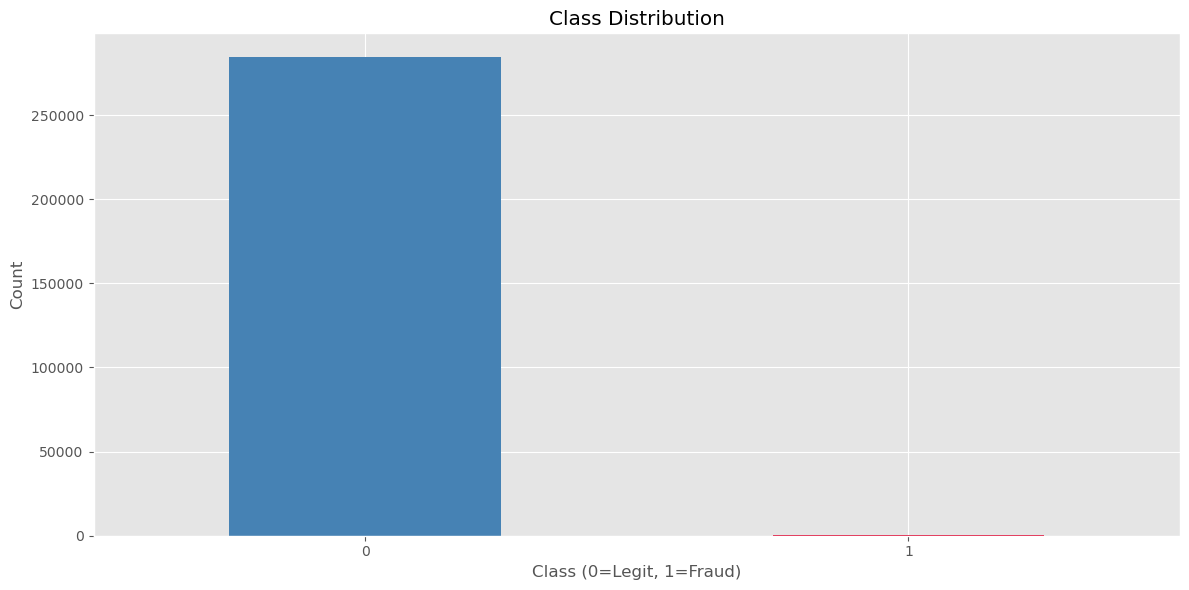

In [3]:
fraud_count = df['Class'].value_counts()
print(f'Legitimate (0): {fraud_count[0]} ({fraud_count[0]/len(df)*100:.2f}%)')
print(f'Fraud (1):     {fraud_count[1]} ({fraud_count[1]/len(df)*100:.4f}%)')

fig, ax = plt.subplots()
fraud_count.plot(kind='bar', color=['steelblue', 'crimson'], ax=ax)
ax.set_title('Class Distribution')
ax.set_xlabel('Class (0=Legit, 1=Fraud)')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'class_distribution.png'), dpi=150)
plt.show()

## 3. Transaction Amount Distribution

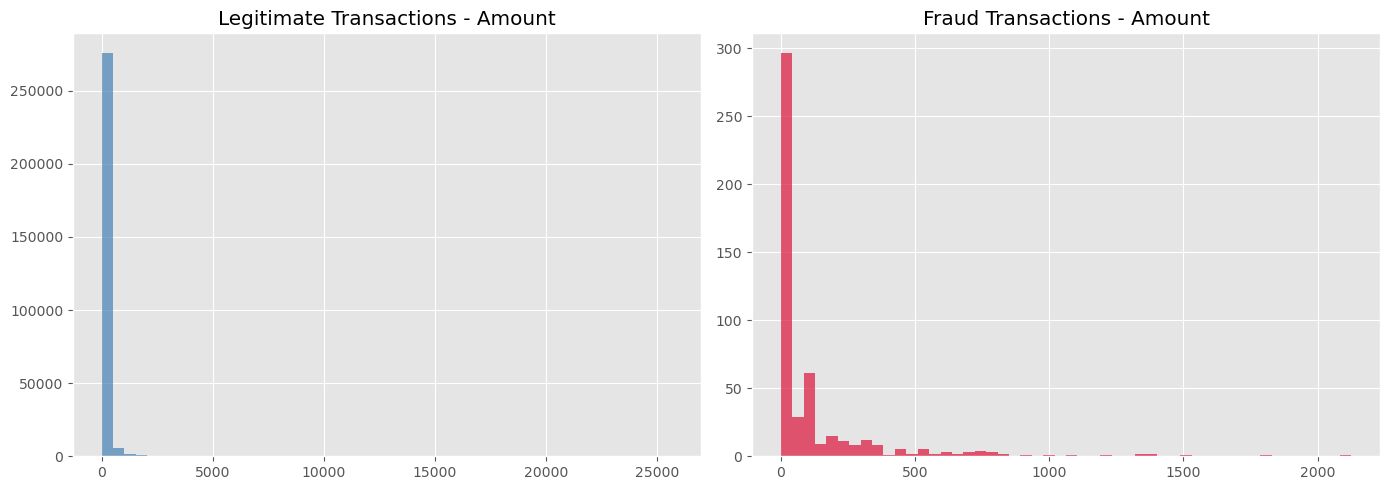

Legit amount stats:
 count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

Fraud amount stats:
 count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[df['Class']==0]['Amount'].hist(bins=50, ax=axes[0], alpha=0.7, color='steelblue')
df[df['Class']==1]['Amount'].hist(bins=50, ax=axes[1], alpha=0.7, color='crimson')

axes[0].set_title('Legitimate Transactions - Amount')
axes[1].set_title('Fraud Transactions - Amount')
plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'amount_distribution.png'), dpi=150)
plt.show()

print('Legit amount stats:\n', df[df['Class']==0]['Amount'].describe())
print('\nFraud amount stats:\n', df[df['Class']==1]['Amount'].describe())

## 4. Feature Correlations with Class

Top 10 correlations with Class:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V11    0.154876
V4     0.133447
V18   -0.111485
Name: Class, dtype: float64


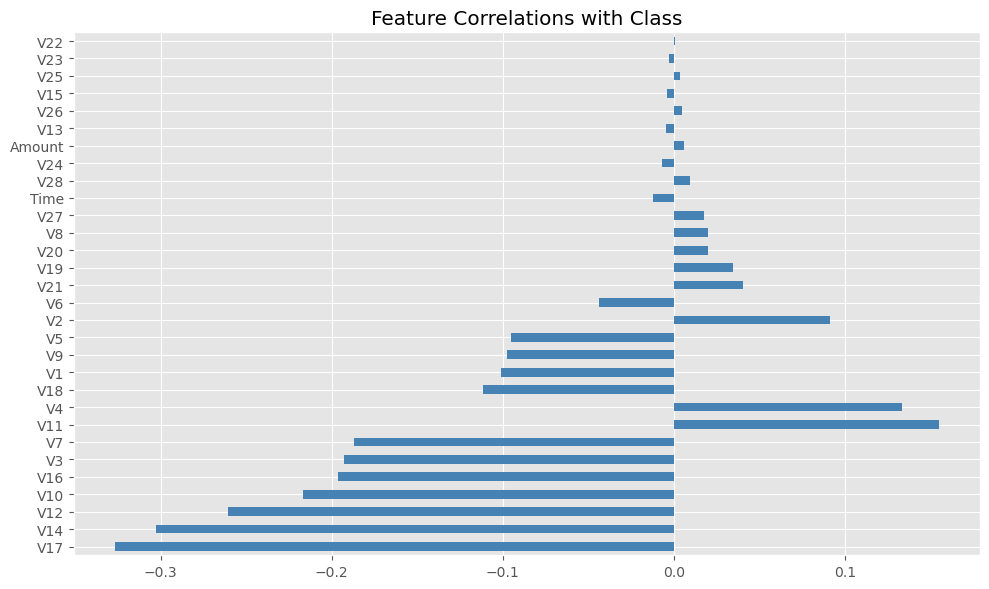

In [5]:
# Top correlations with Class
corrs = df.corr()['Class'].drop('Class').sort_values(key=abs, ascending=False)
print('Top 10 correlations with Class:')
print(corrs.head(10))

fig, ax = plt.subplots(figsize=(10, 6))
corrs.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Correlations with Class')
plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'feature_correlations.png'), dpi=150)
plt.show()

## 5. Key Insights Summary

In [6]:
print('''KEY INSIGHTS:
- Extreme imbalance: ~0.17% fraud transactions (492 out of 284,807)
- Amount: Fraud transactions have higher average amounts
- V1-V28: PCA-transformed features (confidential)
- Time: Seconds elapsed from first transaction in the dataset
- Strategy: SMOTE oversampling + threshold tuning for best performance
''')

KEY INSIGHTS:
- Extreme imbalance: ~0.17% fraud transactions (492 out of 284,807)
- Amount: Fraud transactions have higher average amounts
- V1-V28: PCA-transformed features (confidential)
- Time: Seconds elapsed from first transaction in the dataset
- Strategy: SMOTE oversampling + threshold tuning for best performance

